## Loading The Data
We start by loading the 20 newsgroups dataset's raw text data, and split it into train and test.

In [1]:
from sklearn.datasets import fetch_20newsgroups

# Load the full training and testing dataset.
data_train = fetch_20newsgroups(subset='train', shuffle=True, random_state=42)
data_test = fetch_20newsgroups(subset='test', shuffle=True, random_state=42)

# Get the raw documents and labels.
X_train, y_train = data_train.data, data_train.target
X_test, y_test = data_test.data, data_test.target

# Target names (class labels):
target_names = data_train.target_names

print('Training data samples:', len(X_train))
print('Testing data samples:', len(X_test))
print('Number of classes:', len(target_names))

Training data samples: 11314
Testing data samples: 7532
Number of classes: 20


## Observing a document for example
Let's choose a document from the training set and print it, so we can see how our data looks like before vectorizing.

In [2]:
print('Sample document:')
print(X_train[0])

Sample document:
From: lerxst@wam.umd.edu (where's my thing)
Subject: WHAT car is this!?
Nntp-Posting-Host: rac3.wam.umd.edu
Organization: University of Maryland, College Park
Lines: 15

 I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.

Thanks,
- IL
   ---- brought to you by your neighborhood Lerxst ----







## Vectorizing The Data
We will vectorize the documents using both Count Vectorizer and TF-IDF Vectorizer.
Count Vectorizer use raw counts of words and TF-IDF gives a score based on importance, let's see the difference with a random document example.

In [3]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

import numpy as np
# --------------------
# 1. Fit Vectorizers
# --------------------
tfidf_vect = TfidfVectorizer()
X_train_tfidf = tfidf_vect.fit_transform(X_train)
X_test_tfidf = tfidf_vect.transform(X_test)

count_vect = CountVectorizer()
X_train_count = count_vect.fit_transform(X_train)
X_test_count = count_vect.transform(X_test)

tfidf_vect = TfidfVectorizer() 
X_train_tfidf = tfidf_vect.fit_transform(X_train) 
X_test_tfidf = tfidf_vect.transform(X_test)

print("Count vectorized train data shape:", X_train_count.shape) 
print("TF-IDF vectorized train data shape:", X_train_tfidf.shape)

Count vectorized train data shape: (11314, 130107)
TF-IDF vectorized train data shape: (11314, 130107)


## Visualize a Vectorized Document
Let’s visualize a sample document’s TF-IDF vector. We will select a sample document, extract its TF-IDF scores, and plot the top 10 words with the highest TF-IDF values.

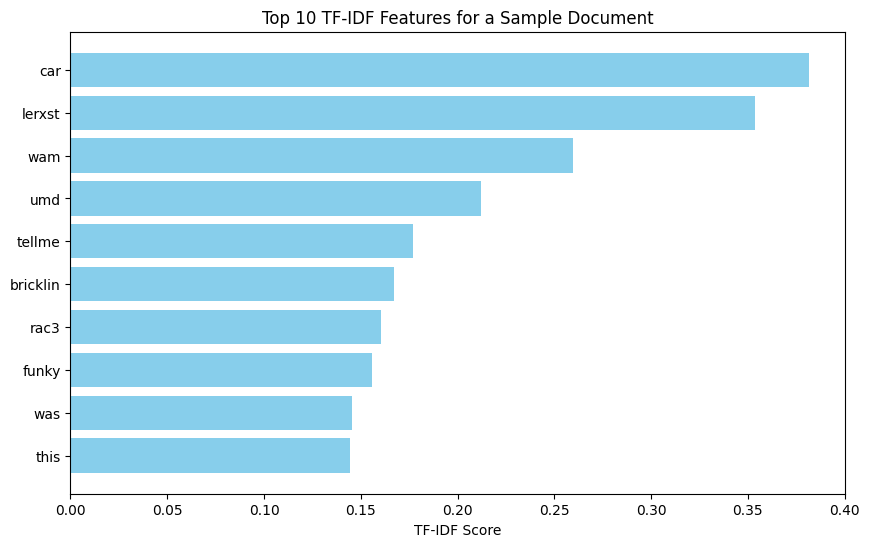

In [4]:
import matplotlib.pyplot as plt

doc_index = 0
doc_tfidf_vec = X_train_tfidf[doc_index] 
doc_tfidf_arr = doc_tfidf_vec.toarray().flatten()

tfidf_features = tfidf_vect.get_feature_names_out()

top_n = 10 
top_indices = np.argsort(doc_tfidf_arr)[-top_n:][::-1]

top_words = [tfidf_features[i] for i in top_indices] 
top_scores = doc_tfidf_arr[top_indices]

plt.figure(figsize=(10, 6)) 
plt.barh(top_words[::-1], top_scores[::-1], color='skyblue') 
plt.xlabel("TF-IDF Score") 
plt.title("Top 10 TF-IDF Features for a Sample Document") 
plt.show()



## Train and Evaluate Multiple Classifiers
We will train four classifiers:
- Logistic Regression
- Decision Tree
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)

### Confusion Matrix Visualization
Here we display the confusion matrix for the Logistic Regression classifier. This will help us see if there are any patterns in the classification errors.


Training Logistic Regression...
Accuracy for Logistic Regression: 0.8278
                          precision    recall  f1-score   support

             alt.atheism       0.80      0.74      0.77       319
           comp.graphics       0.69      0.79      0.74       389
 comp.os.ms-windows.misc       0.75      0.74      0.74       394
comp.sys.ibm.pc.hardware       0.72      0.72      0.72       392
   comp.sys.mac.hardware       0.81      0.83      0.82       385
          comp.windows.x       0.83      0.74      0.78       395
            misc.forsale       0.76      0.90      0.82       390
               rec.autos       0.91      0.89      0.90       396
         rec.motorcycles       0.95      0.95      0.95       398
      rec.sport.baseball       0.88      0.92      0.90       397
        rec.sport.hockey       0.95      0.95      0.95       399
               sci.crypt       0.94      0.88      0.91       396
         sci.electronics       0.76      0.80      0.78       393
 

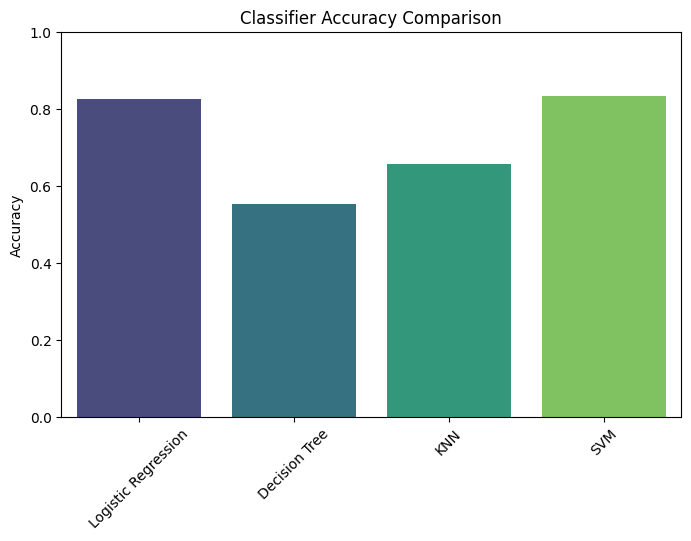

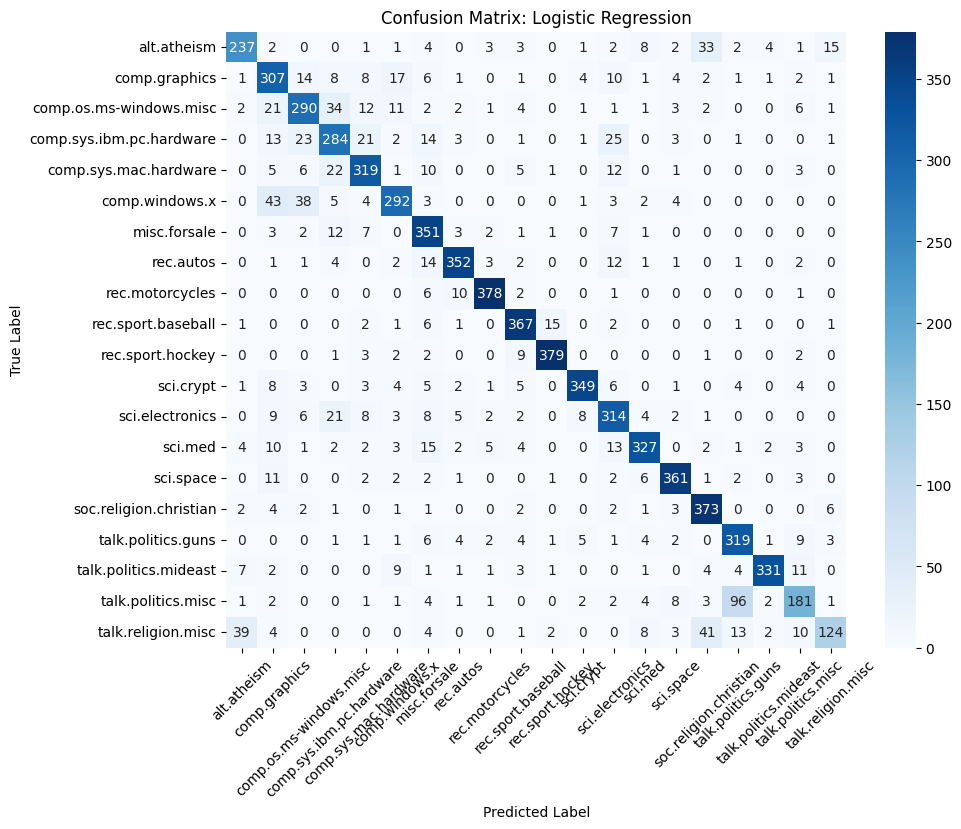

In [5]:
# Import necessary libraries
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Define classifiers in a dictionary
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(), # We go with default k=5
    "SVM": SVC(kernel='linear', random_state=42)
}

# Dictionaries to store accuracy results and confusion matrices
results = {}
conf_matrices = {}

# Loop through each classifier to train and evaluate
for name, clf in classifiers.items():
    print(f"\nTraining {name}...")
    clf.fit(X_train_tfidf, y_train)  # Train classifier on training data
    y_pred = clf.predict(X_test_tfidf)  # Predict on test data

    # Calculate and store accuracy
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    # Print accuracy and classification report
    print(f"Accuracy for {name}: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=target_names))

    # Save confusion matrix for Logistic Regression for later analysis
    if name == "Logistic Regression":
        conf_matrices[name] = confusion_matrix(y_test, y_pred)

# Plot classifier accuracies as a bar chart
plt.figure(figsize=(8, 5))
names = list(results.keys())
acc_values = list(results.values())
sns.barplot(x=names, y=acc_values,hue=names,dodge=False,legend=False, palette="viridis")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.title("Classifier Accuracy Comparison")
plt.xticks(rotation=45)
plt.show()

# Retrieve the confusion matrix for Logistic Regression and plot it
cm = conf_matrices["Logistic Regression"]

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix: Logistic Regression")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

### Analysis of Confusion Matrix and Next Steps
From the confusion matrix we can observe which classes are often confused with one another. For example, if you see a block of high misclassification between two similar topics, that could be an indication that the classifier struggles with subtle differences in language between those topics.

To gain more insight into the classification decisions, we will now inspect the top 3 words that contribute the most (i.e. have the highest weight) to each class in the Logistic Regression classifier.

### Extracting and Visualizing Top 3 Words per Class
Using the coefficients from the Logistic Regression model (which has one weight per feature per class), we extract for each class the top 3 features (words) with the highest positive weights. We then visualize them.

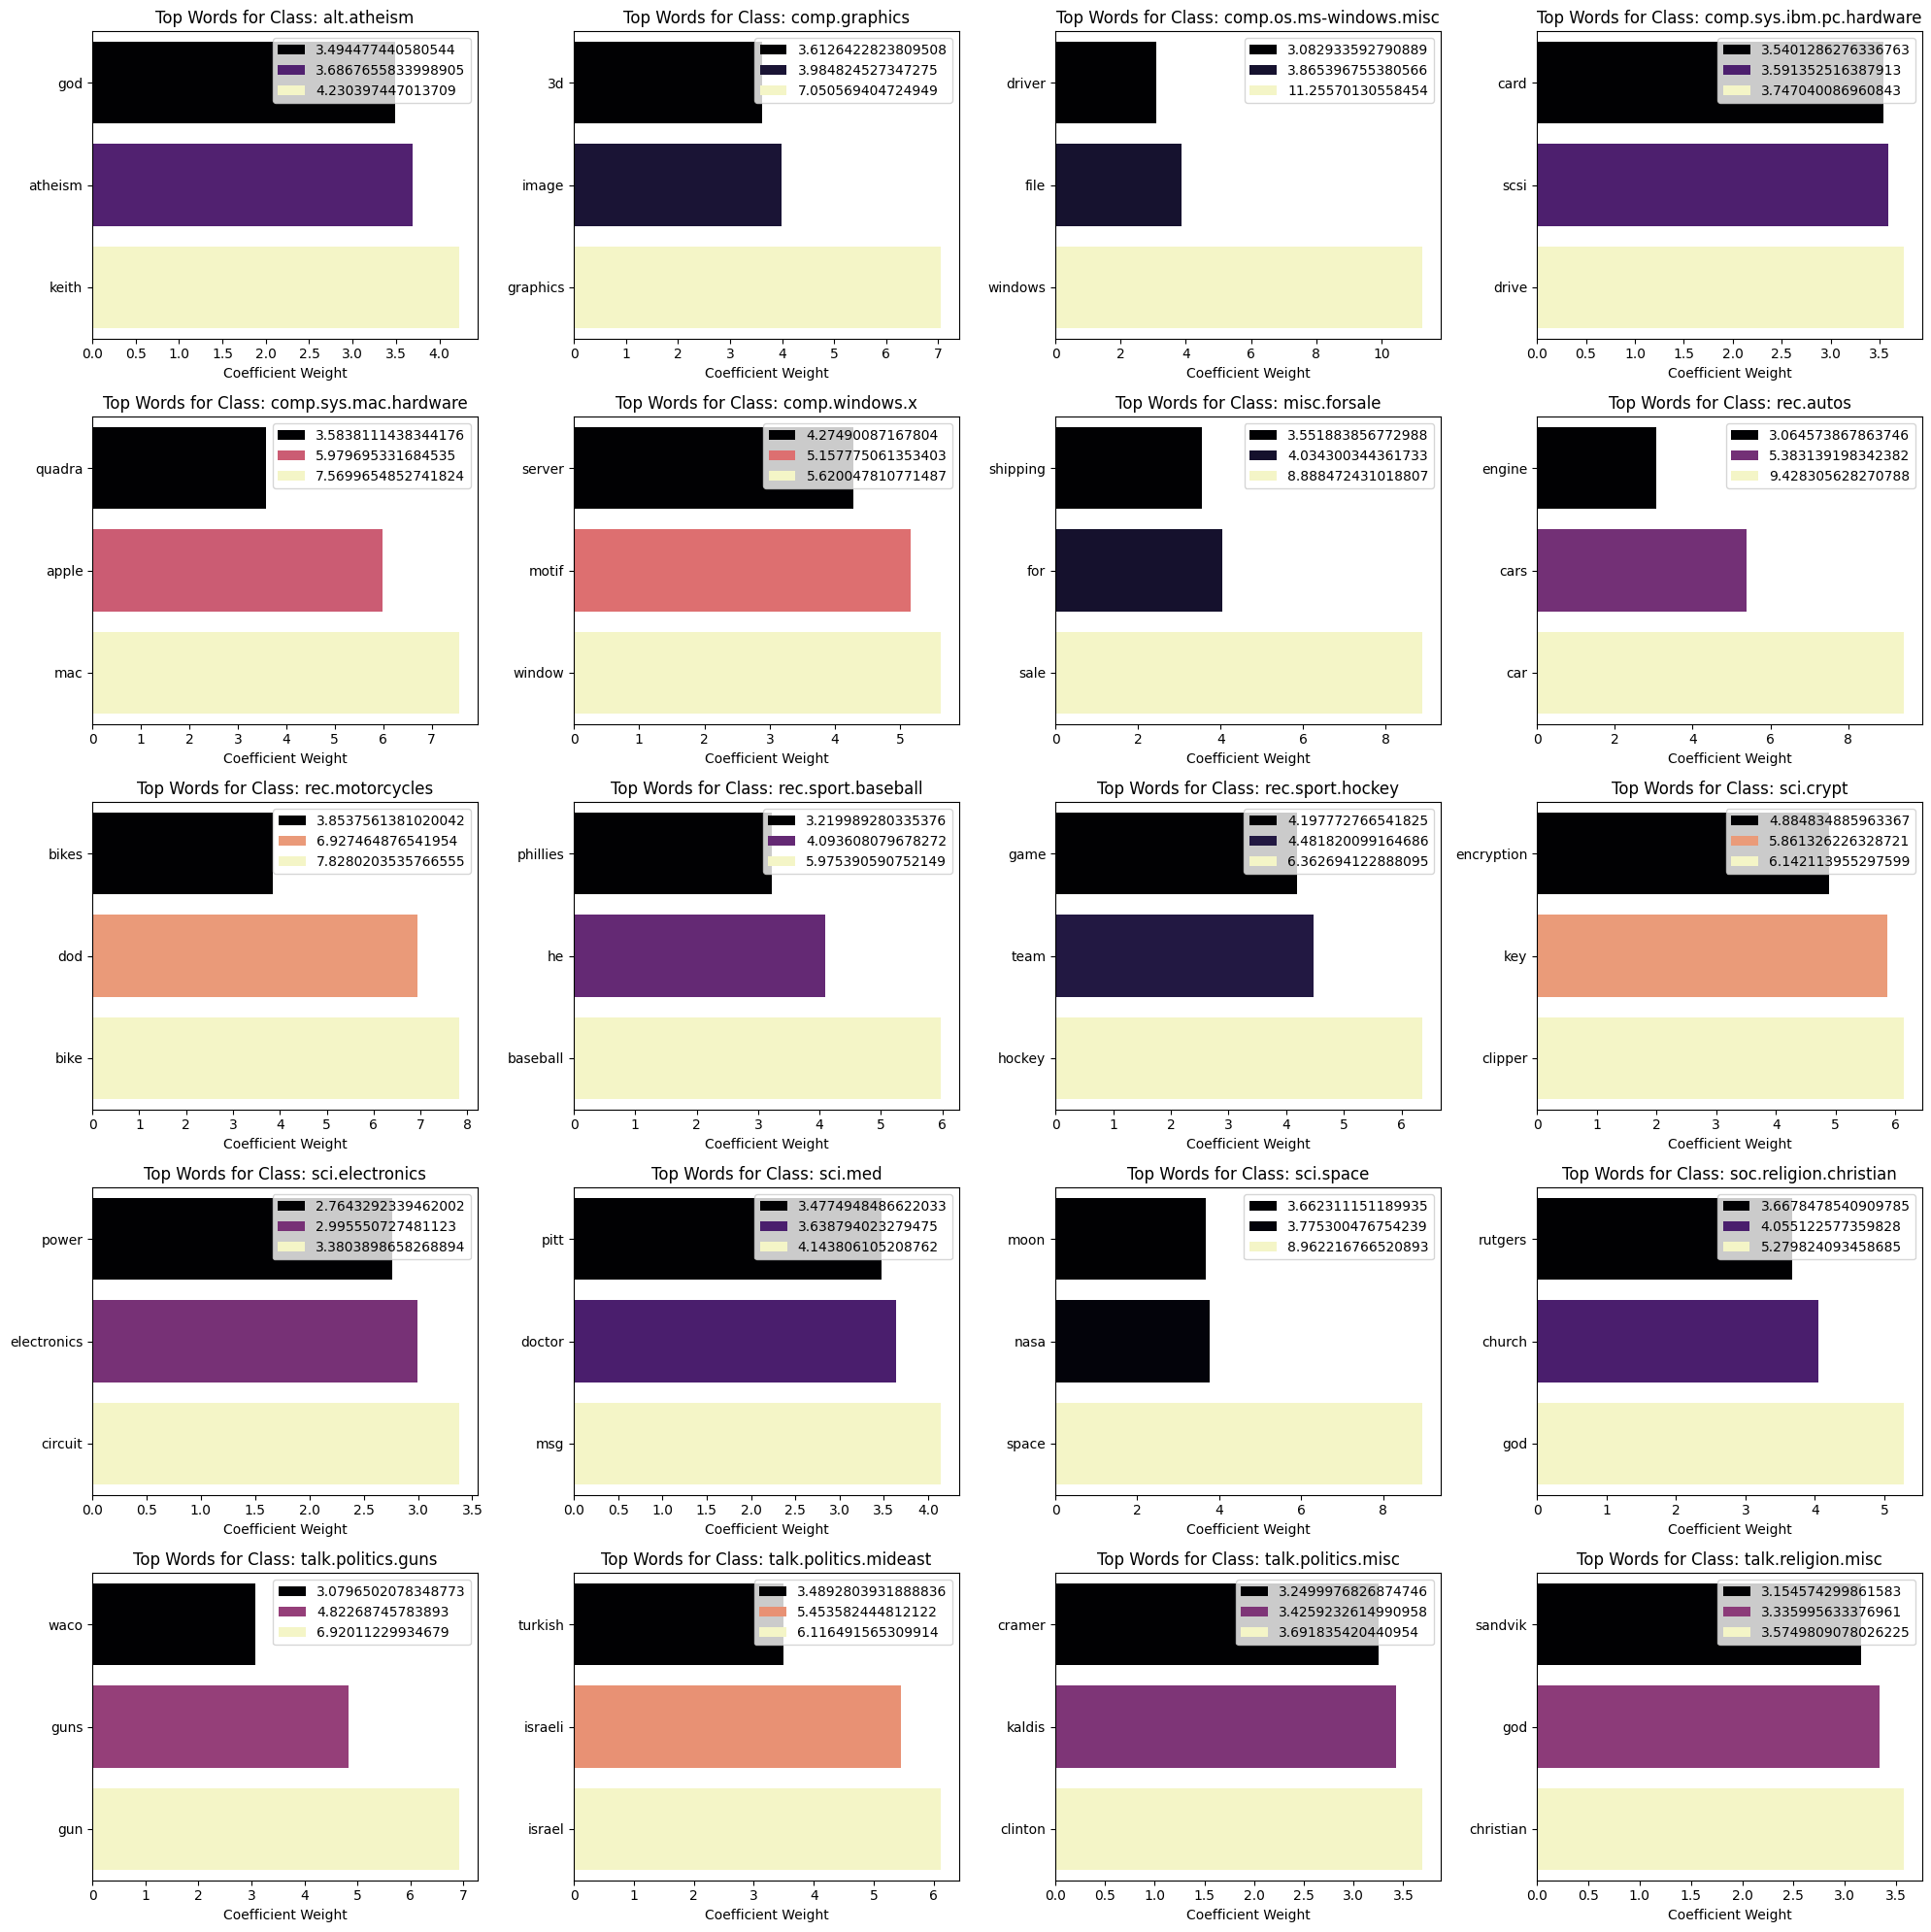

In [6]:
log_reg = classifiers["Logistic Regression"]

coefs = log_reg.coef_
feature_names = tfidf_vect.get_feature_names_out()
top_words_per_class = {}  # dictionary: key = class name, value = (words, weights)

for idx, class_name in enumerate(target_names):
    coef = coefs[idx]  # Get indices of the top 3 coefficients (largest positive weights)
    top3_idx = np.argsort(coef)[-3:]
    top3_words = feature_names[top3_idx]
    top3_weights = coef[top3_idx]
    top_words_per_class[class_name] = (top3_words, top3_weights)

n_classes = len(target_names)
ncols = 4
nrows = (n_classes + ncols - 1) // ncols  # compute rows needed

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 4*nrows))
axes = axes.flatten()

for i, class_name in enumerate(target_names):
    words, weights = top_words_per_class[class_name]
    sns.barplot(x=weights, y=words,hue=weights, ax=axes[i], palette="magma")
    axes[i].set_title(f"Top Words for Class: {class_name}")
    axes[i].set_xlabel("Coefficient Weight")
    axes[i].set_ylabel("")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

